
# **EDA Inicial — Robos a Transeúntes en CDMX**


**Hipótesis:** "Los robos a transeúntes tienden a concentrarse más en viernes y sábado, especialmente en las alcaldías con mayor actividad comercial."

Author: Jorge Valverde-Rebaza
Bloque: TI3001C


# 1) Introducción

En contextos urbanos, la afluencia de personas en zonas comerciales suele aumentar los viernes y sábados por actividades laborales, recreativas y de consumo. Esto podría asociarse con mayor oportunidad delictiva
para robos a transeúntes. Nuestro análisis busca observar patrones temporales (día/hora) y espaciales (alcaldías), contrastando zonas de alta actividad comercial frente a otras.<br><br>

En ese sentido, en este notebook desarrollaremos un análisis exploratorio de datos (EDA) sobre datos abiertos de la **Fiscalia General de Justicia (FGJ)**. Estos datos corresponden al histórico colectado desde 2016 hasta el 31 de enero de 2025, y pueden ser accedidos desde:  https://archivo.datos.cdmx.gob.mx/FGJ/carpetas/carpetasFGJ_acumulado_2025_01.csv

# 2) Metodologia

1. Se prepara la base de datos, limpiando fechas, horas, nombres de alcaldías y eliminando registros inválidos.

2. Se filtran solo los delitos de tipo robo a transeúnte.

3. Se categorizan las alcaldías en dos grupos: zonas de alta actividad comercial y el resto.

4. Se generan variables de análisis: día de la semana y hora del día.

5. Se hacen gráficas descriptivas para ver patrones: cantidad de robos por día de la semana, comparación entre zonas comerciales y no comerciales, perfil horario viernes/sábado contra otros días, etc.

6. Se crea un mapa interactivo (con puntos calientes) que muestra dónde se concentran los robos viernes y sábado en zonas comerciales.

7. Para concluir, se discute si los datos apoyan la hipótesis, se reconocen limitaciones y se sugieren próximos pasos .

# 3) Resultados

## 3.1) Paqueteria y entorno del proyecto

Cargamos aqui, todos los paquetes, funciones auxiliares, variables globales, y todo elemento que necesitaremos a lo largo del proyecto.

### PAQUETERIA

In [1]:
# Traditional data science package
import pandas as pd #handling data in dataframe format
import numpy as np #handling linear algebra in general
import seaborn as sns #stylized data visualization
import matplotlib.pyplot as plt #basic data visualization
from matplotlib.colors import Normalize

# Other packages
import re
import warnings
warnings.filterwarnings('ignore')

# Maps packages
import geopandas as gpd
from shapely.geometry import Point, box
from mpl_toolkits.axes_grid1 import make_axes_locatable
import folium
from folium.plugins import HeatMap

# To handle our data from Google Drive
from google.colab import drive

### CONFIGURACIÓN

In [2]:
# Le indicamos a Pandas que siempre muestre hasta 50 columnas completas en lugar de cortarlas con “...”.
pd.set_option("display.max_columns", 50)

# Configura el formato numérico para mostrar todos los números decimales de tipo float.
# En este caso: ´:,.2f´ significa “poner separador de miles (coma) y mostrar 2 decimales”.
# Es decir, sin formato: 1234567.89123 ... con formato sería: 1,234,567.89
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [3]:
# High-impact visual defaults
sns.set_theme(style="whitegrid", context="talk", palette="deep")

### VARIABLES GLOBALES

In [4]:
# Patrón regex robusto para identificar "ROBO A TRANSEÚNTE" (tolerando acentos en la U)
RT_PATTERN = re.compile(r"ROBO\\s+A\\s+TRANSE[UÚ]NTE")



# Hay varios tipos de robos, seleccionamos algunos prefijos de interés (normalizados) ---
DELITOS_PREFIJOS = [
    "ROBO A PASAJERO",
    "ROBO A TRANSEUNTE",
    "ROBO DE DINERO",
    "ROBO DE OBJETOS",
    "ROBO A NEGOCIO",
]


### FUNCIONES

In [5]:
def _to_datetime_safe(s, fmt=None):
    """
    Convierte una serie/columna a formato datetime.
    - Si encuentra un valor inválido lo convierte en NaT (Not a Time).
    - Parámetros:
        s   -> serie o columna de pandas con fechas
        fmt -> formato esperado (opcional, ej: "%H:%M:%S")
    """
    return pd.to_datetime(s, format=fmt, errors="coerce")


def _strip_accents_upper(text):
    """
    Normaliza cadenas de texto quitando acentos y convirtiendo todo a MAYÚSCULAS.
    - Si el valor es NaN, lo devuelve tal cual.
    - Ejemplo: "Álvaro Obregón" -> "ALVARO OBREGON"
    """
    if pd.isna(text):
        return text
    repl = (("á","a"),("é","e"),("í","i"),("ó","o"),("ú","u"),("ü","u"),("ñ","n"))
    t = str(text).lower()
    for a,b in repl:
        t = t.replace(a,b)
    return t.upper()


def prepare_data(df):
    """
    Prepara el DataFrame original aplicando varios pasos de limpieza:
    - Convierte fecha y hora a formato datetime.
    - Elimina registros sin fecha o sin delito.
    - Normaliza texto en columnas clave (delito, alcaldía, colonia).
    - Crea nuevas columnas derivadas:
        * dow: día de la semana como número (0=Lunes ... 6=Domingo)
        * dia_semana: día de la semana en texto
        * hora_num: hora del día (0–23)
    - Filtra registros con coordenadas fuera del rango de CDMX.
    Retorna: DataFrame limpio y listo para análisis.
    """
    df = df.copy()
    df["fecha_hecho_dt"] = _to_datetime_safe(df.get("fecha_hecho"))
    df["hora_hecho_dt"]  = _to_datetime_safe(df.get("hora_hecho"), fmt="%H:%M:%S")

    # Filtrado: quitar filas sin fecha o sin delito
    df = df[~df["fecha_hecho_dt"].isna() & df["delito"].notna()].copy()

    # Normalizar texto en columnas clave
    for col in ["delito","categoria_delito","alcaldia_hecho","colonia_hecho"]:
        df[col+"_N"] = df[col].apply(_strip_accents_upper)

    # Día de la semana
    df["dow"] = df["fecha_hecho_dt"].dt.weekday
    dow_map = {0:"LUNES",1:"MARTES",2:"MIERCOLES",3:"JUEVES",4:"VIERNES",5:"SABADO",6:"DOMINGO"}
    df["dia_semana"] = df["dow"].map(dow_map)

    # Hora numérica
    df["hora_num"] = df["hora_hecho_dt"].dt.hour

    # Filtrar coordenadas fuera de CDMX
    mask_geo = (
        df["latitud"].between(18.9, 19.9, inclusive="both") &
        df["longitud"].between(-99.5, -98.9, inclusive="both")
    )

    return df[mask_geo].copy()




def filter_delitos_interes(df, col_delito="delito", prefijos=DELITOS_PREFIJOS):
    """
    Filtra filas cuyo 'delito' COMIENZA con alguno de los prefijos indicados.
    - Robusto a acentos/mayúsculas (normaliza antes de comparar).
    - Crea columna 'delito_N' si no existe (normalizada).
    - Crea columna 'tipo_robo' con el prefijo detectado.
    Retorna: DataFrame filtrado.
    """
    if col_delito not in df.columns:
        # Si no existe la columna de delito, devolvemos vacío seguro
        return df.iloc[0:0].copy()

    dfx = df.copy()

    # Asegurar columna normalizada
    if "delito_N" not in dfx.columns:
        dfx["delito_N"] = dfx[col_delito].apply(_strip_accents_upper)

    # Normalizar los prefijos una única vez
    prefijos_norm = [_strip_accents_upper(p) for p in prefijos]

    # Construir máscara por startswith de manera vectorizada
    # (aplica OR lógico entre todos los prefijos)
    s = dfx["delito_N"].fillna("")
    mask = False
    for p in prefijos_norm:
        mask = mask | s.str.startswith(p, na=False)

    out = dfx[mask].copy()

    # Derivar 'tipo_robo' según el prefijo que matcheó primero
    def _detectar_prefijo(val):
        for p in prefijos_norm:
            if str(val).startswith(p):
                return p
        return np.nan

    out["tipo_robo"] = out["delito_N"].apply(_detectar_prefijo)
    return out

def tag_zona_comercial(df, top_list=None):
    """
    Clasifica las alcaldías en dos categorías:
    - ALTA_ACTIVIDAD (zonas con mayor concentración comercial)
    - OTRAS
    La lista de alcaldías de alta actividad se puede personalizar.
    Retorna: DataFrame con columna adicional 'zona_comercial'.
    """
    if top_list is None:
        top_list = ["CUAUHTEMOC","BENITO JUAREZ","MIGUEL HIDALGO","COYOACAN"]
    df = df.copy()
    df["zona_comercial"] = np.where(df["alcaldia_hecho_N"].isin(top_list), "ALTA_ACTIVIDAD", "OTRAS")
    return df


def safe_value_counts(df, col, normalize=False):
    """
    Calcula las frecuencias de valores de una columna de forma segura.
    - Si normalize=True devuelve proporciones (%).
    - Incluye los valores nulos (NaN) en el conteo.
    Retorna: Serie con frecuencias absolutas o relativas.
    """
    return df[col].value_counts(normalize=normalize, dropna=False)


## 3.2) Trabajando con los datos

In [7]:
# acessing our data from Google Drive
drive.mount('/drive')
path = '/drive/My Drive/Colab Notebooks/reto-Thales/'
print(f'Files will be access from: {path}')

Mounted at /drive
Files will be access from: /drive/My Drive/Colab Notebooks/reto-Thales/


### LECTURA DE DATOS

In [8]:
data = pd.read_csv(path + 'data/carpetasFGJ_acumulado_2025_01.csv')
data

,anio_inicio,mes_inicio,fecha_inicio,hora_inicio,anio_hecho,mes_hecho,fecha_hecho,hora_hecho,delito,categoria_delito,competencia,fiscalia,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,alcaldia_hecho,alcaldia_catalogo,municipio_hecho,latitud,longitud
0,2016,Enero,2016-01-01,00:00:00,"2,015.00",Diciembre,2015-12-31,16:30:00,LESIONES CULPOSAS POR TRANSITO VEHICULAR EN CO...,DELITO DE BAJO IMPACTO,NaN,INVESTIGACIÓN EN TLALPAN,TLP-4,UI-2CD,JARDINES EN LA MONTAÑA,Jardines En La Montaña,TLALPAN,NaN,CDMX,19.30,-99.21
1,2016,Enero,2016-01-01,00:00:00,"2,015.00",Diciembre,2015-12-31,22:40:00,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,NaN,INVESTIGACIÓN EN TLALPAN,TLP-1,UI-2CD,LOMAS DE PADIERNA,Lomas De Padierna,TLALPAN,NaN,CDMX,19.29,-99.22
2,2016,Enero,2016-01-01,00:00:00,"2,016.00",Enero,2016-01-01,00:20:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIO...,NaN,INVESTIGACIÓN EN IZTAPALAPA,IZP-2,UI-2CD,SAN ANTONIO CULHUACÁN,Barrio San Antonio Culhuacan,IZTAPALAPA,NaN,CDMX,19.34,-99.11
3,2016,Enero,2016-01-01,00:00:00,"2,015.00",Diciembre,2015-12-31,22:00:00,ROBO DE VEHICULO DE SERVICIO PARTICULAR SIN VI...,ROBO DE VEHÍCULO CON Y SIN VIOLENCIA,NaN,INVESTIGACIÓN EN GUSTAVO A. MADERO,GAM-8,UI-2CD,SAN JUAN DE ARAGÓN II SECCIÓN,San Juan De Aragon Ii Seccion,GUSTAVO A. MADERO,NaN,CDMX,19.45,-99.09
4,2016,Enero,2016-01-01,00:00:00,"2,015.00",Diciembre,2015-12-31,22:30:00,HOMICIDIOS INTENCIONALES (OTROS),HOMICIDIO DOLOSO,NaN,INVESTIGACIÓN EN BENITO JUÁREZ,BJ-1,UI-2SD,NATIVITAS,Nativitas,BENITO JUAREZ,NaN,CDMX,19.38,-99.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2098738,2024,Noviembre,2024-11-25 19:35:00,19:35:00,"2,024.00",Noviembre,2024-11-25 17:32:00,17:32:00,TENTATIVA DE EXTORSION,DELITO DE BAJO IMPACTO,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN DEL DELITO DE SECUESTRO,E,2 CON DETENIDO 2 C/D,MIGUEL HIDALGO 3A SECCIÓN,Miguel Hidalgo 3a Seccion,TLALPAN,NaN,CDMX,19.28,-99.21
2098739,2024,Noviembre,2024-11-26 19:53:00,19:53:00,"2,024.00",Noviembre,2024-11-25 11:20:00,11:20:00,EXTORSION,DELITO DE BAJO IMPACTO,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN IZTAP...,IZP-4,UI-3SD,SANTA BÁRBARA,Barrio Santa Barbara,IZTAPALAPA,NaN,CDMX,19.36,-99.10
2098740,2024,Noviembre,2024-11-28 16:27:00,16:27:00,"2,024.00",Noviembre,2024-11-28 13:15:00,13:15:00,EXTORSION,DELITO DE BAJO IMPACTO,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN DEL DELITO DE SECUESTRO,E,2 CON DETENIDO 2 C/D,AMPLIACIÓN TORRE BLANCA,Pensil Norte,MIGUEL HIDALGO,NaN,CDMX,19.45,-99.20
2098741,2024,Noviembre,2024-11-28 23:42:00,23:42:00,"2,024.00",Noviembre,2024-11-26 02:50:00,02:50:00,EXTORSION,DELITO DE BAJO IMPACTO,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN DEL DELITO DE SECUESTRO,E,2 CON DETENIDO 2 C/D,ESPERANZA,Esperanza,CUAUHTEMOC,NaN,CDMX,19.42,-99.13


In [9]:
# Mostramos el tamaño del DataFrame original (número de filas y columnas)
print("Tamaño original:", data.shape)

Tamaño original: (2098743, 21)


### LIMPIEZA DE DATOS

In [10]:
# Aplicamos la función de limpieza y preparación al DataFrame original
# Esto convierte fechas/horas, normaliza textos y filtra coordenadas válidas
df_clean = prepare_data(data)

# Mostramos el tamaño después del proceso de limpieza
print("Tras limpieza:", df_clean.shape)

Tras limpieza: (1946840, 30)


In [11]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1946840 entries, 0 to 2045175
Data columns (total 30 columns):
 #   Column                Dtype         
---  ------                -----         
 0   anio_inicio           int64         
 1   mes_inicio            object        
 2   fecha_inicio          object        
 3   hora_inicio           object        
 4   anio_hecho            float64       
 5   mes_hecho             object        
 6   fecha_hecho           object        
 7   hora_hecho            object        
 8   delito                object        
 9   categoria_delito      object        
 10  competencia           object        
 11  fiscalia              object        
 12  agencia               object        
 13  unidad_investigacion  object        
 14  colonia_hecho         object        
 15  colonia_catalogo      object        
 16  alcaldia_hecho        object        
 17  alcaldia_catalogo     object        
 18  municipio_hecho       object        
 19  latit

Aqui es importante denerno un minuto y analizar. El df_clean tiene más columnas que el dataframe original porque no solo guarda los datos crudos, sino también versiones limpias y variables derivadas que son esenciales para probar la hipótesis.

Nuevas columnas creadas (del 21 en adelante)

| **Columna**          | **Origen**                          | **Utilidad en el análisis**                                                                                    |
| -------------------- | ----------------------------------- | -------------------------------------------------------------------------------------------------------------- |
| `fecha_hecho_dt`     | Derivada de `fecha_hecho`           | Convertida a formato datetime; permite extraer año, mes, día y operar con fechas de forma segura.              |
| `hora_hecho_dt`      | Derivada de `hora_hecho`            | Hora en formato datetime; facilita agrupar y analizar por hora del día.                                        |
| `delito_N`           | Normalización de `delito`           | Texto limpio (mayúsculas, sin acentos, ñ→N); permite filtrar “ROBO A TRANSEÚNTE” sin problemas de acentuación. |
| `categoria_delito_N` | Normalización de `categoria_delito` | Agrupaciones consistentes sin diferencias ortográficas (ej. “Robo simple” vs “ROBO SIMPLE”).                   |
| `alcaldia_hecho_N`   | Normalización de `alcaldia_hecho`   | Indispensable para clasificar alcaldías en zonas de **alta actividad comercial** vs **otras**.                 |
| `colonia_hecho_N`    | Normalización de `colonia_hecho`    | Permite agrupar colonias aunque tengan acentos o mayúsculas distintas.                                         |
| `dow`                | Derivada de `fecha_hecho_dt`        | Día de la semana como número (0=Lunes … 6=Domingo); útil para cálculos y modelos estadísticos.                 |
| `dia_semana`         | Derivada de `dow`                   | Día de la semana en texto en español; más legible para gráficas y presentaciones.                              |
| `hora_num`           | Derivada de `hora_hecho_dt`         | Número entero de la hora (0–23); permite construir perfiles horarios (ej. picos nocturnos en viernes/sábado).  |


### FILTRADO POR DELITO DE INTERÉS

En este momento, nuestro interes es trabajar con un tipo específico de delito: robos a transeuntes.

Sin embargo, ese tipo de delito no es explícito en el dataset. De esa manera, seleccionamos algunos delitos que pueden ser asociados al delito que es de nuestro interés, es decir, delitos que comienzan con:  ROBO A PASAJERO, ROBO A TRANSEUNTE,  ROBO DE DINERO, ROBO DE OBJETOS, y ROBO A NEGOCIO.

In [12]:
# Filtrado por prefijos de interés (en vez de filter_robo_transeunte)
df_rt = filter_delitos_interes(df_clean, col_delito="delito", prefijos=DELITOS_PREFIJOS)


# Mostramos el tamaño del subconjunto final solo con robos a transeúnte
print("Robos a transeúnte:", df_rt.shape)

Robos a transeúnte: (517546, 31)


In [13]:
df_rt

,anio_inicio,mes_inicio,fecha_inicio,hora_inicio,anio_hecho,mes_hecho,fecha_hecho,hora_hecho,delito,categoria_delito,competencia,fiscalia,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,alcaldia_hecho,alcaldia_catalogo,municipio_hecho,latitud,longitud,fecha_hecho_dt,hora_hecho_dt,delito_N,categoria_delito_N,alcaldia_hecho_N,colonia_hecho_N,dow,dia_semana,hora_num,tipo_robo
1,2016,Enero,2016-01-01,00:00:00,"2,015.00",Diciembre,2015-12-31,22:40:00,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,NaN,INVESTIGACIÓN EN TLALPAN,TLP-1,UI-2CD,LOMAS DE PADIERNA,Lomas De Padierna,TLALPAN,NaN,CDMX,19.29,-99.22,2015-12-31,1900-01-01 22:40:00,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,TLALPAN,LOMAS DE PADIERNA,3,JUEVES,22.00,ROBO A PASAJERO
2,2016,Enero,2016-01-01,00:00:00,"2,016.00",Enero,2016-01-01,00:20:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIO...,NaN,INVESTIGACIÓN EN IZTAPALAPA,IZP-2,UI-2CD,SAN ANTONIO CULHUACÁN,Barrio San Antonio Culhuacan,IZTAPALAPA,NaN,CDMX,19.34,-99.11,2016-01-01,1900-01-01 00:20:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VIA PUBLICA CON Y SIN VIO...,IZTAPALAPA,SAN ANTONIO CULHUACAN,4,VIERNES,0.00,ROBO A TRANSEUNTE
5,2016,Enero,2016-01-01,00:00:00,"2,015.00",Diciembre,2015-12-31,14:40:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIO...,NaN,INVESTIGACIÓN EN COYOACÁN,COY-5,UI-2CD,CULHUACÁN CTM SECCIÓN VII,Culhuacan Ctm Seccion Vi,COYOACAN,NaN,CDMX,19.33,-99.11,2015-12-31,1900-01-01 14:40:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VIA PUBLICA CON Y SIN VIO...,COYOACAN,CULHUACAN CTM SECCION VII,3,JUEVES,14.00,ROBO A TRANSEUNTE
6,2016,Enero,2016-01-01,00:00:00,"2,015.00",Diciembre,2015-12-31,17:00:00,ROBO DE OBJETOS,DELITO DE BAJO IMPACTO,NaN,INVESTIGACIÓN EN IZTAPALAPA,IZP-4,UI-2CD,LEYES DE REFORMA 3A SECCIÓN,Leyes De Reforma 3a Seccion,IZTAPALAPA,NaN,CDMX,19.38,-99.07,2015-12-31,1900-01-01 17:00:00,ROBO DE OBJETOS,DELITO DE BAJO IMPACTO,IZTAPALAPA,LEYES DE REFORMA 3A SECCION,3,JUEVES,17.00,ROBO DE OBJETOS
14,2016,Enero,2016-01-01,00:00:00,"2,015.00",Diciembre,2015-12-16,02:00:00,ROBO DE OBJETOS,DELITO DE BAJO IMPACTO,NaN,INVESTIGACIÓN EN BENITO JUÁREZ,BJ-1,UI-2SD,DEL VALLE CENTRO,Del Valle Norte,BENITO JUAREZ,NaN,CDMX,19.40,-99.16,2015-12-16,1900-01-01 02:00:00,ROBO DE OBJETOS,DELITO DE BAJO IMPACTO,BENITO JUAREZ,DEL VALLE CENTRO,2,MIERCOLES,2.00,ROBO DE OBJETOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2045164,2024,Octubre,2024-10-31 00:00:00,23:40:00,"2,024.00",Octubre,2024-10-28,06:47:00,ROBO DE OBJETOS DEL INTERIOR DE UN VEHICULO,DELITO DE BAJO IMPACTO,FUERO COMUN,AGENCIA DE DENUNCIA DIGITAL,CEN-A,UI-1SD,CONDESA,Condesa,CUAUHTEMOC,NaN,CDMX,19.41,-99.18,2024-10-28,1900-01-01 06:47:00,ROBO DE OBJETOS DEL INTERIOR DE UN VEHICULO,DELITO DE BAJO IMPACTO,CUAUHTEMOC,CONDESA,0,LUNES,6.00,ROBO DE OBJETOS
2045167,2024,Octubre,2024-10-31 00:00:00,23:42:00,"2,024.00",Octubre,2024-10-31,22:33:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIO...,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLÁHUAC,TLH-1,UI-1CD,MIGUEL HIDALGO,Miguel Hidalgo,TLAHUAC,NaN,CDMX,19.29,-99.04,2024-10-31,1900-01-01 22:33:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VIA PUBLICA CON Y SIN VIO...,TLAHUAC,MIGUEL HIDALGO,3,JUEVES,22.00,ROBO A TRANSEUNTE
2045168,2024,Octubre,2024-10-31 00:00:00,23:42:00,"2,024.00",Octubre,2024-10-30,19:00:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIO...,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN ALVAR...,UAT-AO-4,UI-1SD,AMPLIACION DOS RIOS,Dos Rios Del Pueblo De Santa Lucia,ALVARO OBREGON,NaN,CDMX,19.36,-99.25,2024-10-30,1900-01-01 19:00:00,RO

Recuerda que las nuevas columnas delito_N y	categoria_delito_N corresponden al delito y categoria del delito, debidamente normalizados (mayúsculas, sin acentos, etc.).

In [14]:
# Filtrado por alcaldías en "ALTA_ACTIVIDAD" (zonas comerciales) y "OTRAS"
df_rt = tag_zona_comercial(df_rt)

print("Filtrado (delitos de interés):", df_rt.shape)

Filtrado (delitos de interés): (517546, 32)


In [15]:
df_rt

,anio_inicio,mes_inicio,fecha_inicio,hora_inicio,anio_hecho,mes_hecho,fecha_hecho,hora_hecho,delito,categoria_delito,competencia,fiscalia,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,alcaldia_hecho,alcaldia_catalogo,municipio_hecho,latitud,longitud,fecha_hecho_dt,hora_hecho_dt,delito_N,categoria_delito_N,alcaldia_hecho_N,colonia_hecho_N,dow,dia_semana,hora_num,tipo_robo,zona_comercial
1,2016,Enero,2016-01-01,00:00:00,"2,015.00",Diciembre,2015-12-31,22:40:00,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,NaN,INVESTIGACIÓN EN TLALPAN,TLP-1,UI-2CD,LOMAS DE PADIERNA,Lomas De Padierna,TLALPAN,NaN,CDMX,19.29,-99.22,2015-12-31,1900-01-01 22:40:00,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,TLALPAN,LOMAS DE PADIERNA,3,JUEVES,22.00,ROBO A PASAJERO,OTRAS
2,2016,Enero,2016-01-01,00:00:00,"2,016.00",Enero,2016-01-01,00:20:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIO...,NaN,INVESTIGACIÓN EN IZTAPALAPA,IZP-2,UI-2CD,SAN ANTONIO CULHUACÁN,Barrio San Antonio Culhuacan,IZTAPALAPA,NaN,CDMX,19.34,-99.11,2016-01-01,1900-01-01 00:20:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VIA PUBLICA CON Y SIN VIO...,IZTAPALAPA,SAN ANTONIO CULHUACAN,4,VIERNES,0.00,ROBO A TRANSEUNTE,OTRAS
5,2016,Enero,2016-01-01,00:00:00,"2,015.00",Diciembre,2015-12-31,14:40:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIO...,NaN,INVESTIGACIÓN EN COYOACÁN,COY-5,UI-2CD,CULHUACÁN CTM SECCIÓN VII,Culhuacan Ctm Seccion Vi,COYOACAN,NaN,CDMX,19.33,-99.11,2015-12-31,1900-01-01 14:40:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VIA PUBLICA CON Y SIN VIO...,COYOACAN,CULHUACAN CTM SECCION VII,3,JUEVES,14.00,ROBO A TRANSEUNTE,ALTA_ACTIVIDAD
6,2016,Enero,2016-01-01,00:00:00,"2,015.00",Diciembre,2015-12-31,17:00:00,ROBO DE OBJETOS,DELITO DE BAJO IMPACTO,NaN,INVESTIGACIÓN EN IZTAPALAPA,IZP-4,UI-2CD,LEYES DE REFORMA 3A SECCIÓN,Leyes De Reforma 3a Seccion,IZTAPALAPA,NaN,CDMX,19.38,-99.07,2015-12-31,1900-01-01 17:00:00,ROBO DE OBJETOS,DELITO DE BAJO IMPACTO,IZTAPALAPA,LEYES DE REFORMA 3A SECCION,3,JUEVES,17.00,ROBO DE OBJETOS,OTRAS
14,2016,Enero,2016-01-01,00:00:00,"2,015.00",Diciembre,2015-12-16,02:00:00,ROBO DE OBJETOS,DELITO DE BAJO IMPACTO,NaN,INVESTIGACIÓN EN BENITO JUÁREZ,BJ-1,UI-2SD,DEL VALLE CENTRO,Del Valle Norte,BENITO JUAREZ,NaN,CDMX,19.40,-99.16,2015-12-16,1900-01-01 02:00:00,ROBO DE OBJETOS,DELITO DE BAJO IMPACTO,BENITO JUAREZ,DEL VALLE CENTRO,2,MIERCOLES,2.00,ROBO DE OBJETOS,ALTA_ACTIVIDAD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2045164,2024,Octubre,2024-10-31 00:00:00,23:40:00,"2,024.00",Octubre,2024-10-28,06:47:00,ROBO DE OBJETOS DEL INTERIOR DE UN VEHICULO,DELITO DE BAJO IMPACTO,FUERO COMUN,AGENCIA DE DENUNCIA DIGITAL,CEN-A,UI-1SD,CONDESA,Condesa,CUAUHTEMOC,NaN,CDMX,19.41,-99.18,2024-10-28,1900-01-01 06:47:00,ROBO DE OBJETOS DEL INTERIOR DE UN VEHICULO,DELITO DE BAJO IMPACTO,CUAUHTEMOC,CONDESA,0,LUNES,6.00,ROBO DE OBJETOS,ALTA_ACTIVIDAD
2045167,2024,Octubre,2024-10-31 00:00:00,23:42:00,"2,024.00",Octubre,2024-10-31,22:33:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIO...,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLÁHUAC,TLH-1,UI-1CD,MIGUEL HIDALGO,Miguel Hidalgo,TLAHUAC,NaN,CDMX,19.29,-99.04,2024-10-31,1900-01-01 22:33:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VIA PUBLICA CON Y SIN VIO...,TLAHUAC,MIGUEL HIDALGO,3,JUEVES,22.00,ROBO A TRANSEUNTE,OTRAS
2045168,2024,Octubre,2024-10-31 00:00:00,23:42:00,"2,024.00",Octubre,2024-10-30,19:00:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIO...,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN ALVAR...,UAT-AO-4,UI-1SD,AMPLIACION DOS RIOS,Dos Rios Del Pueb

Ahora tenemos una nueva columna, llamada zona_comercial, que indica si un delito ocurrió en una zona de alta actividad comercial, o no.

## 3.3) Visualizaciones

### ROBOS POR DIA DE SEMANA

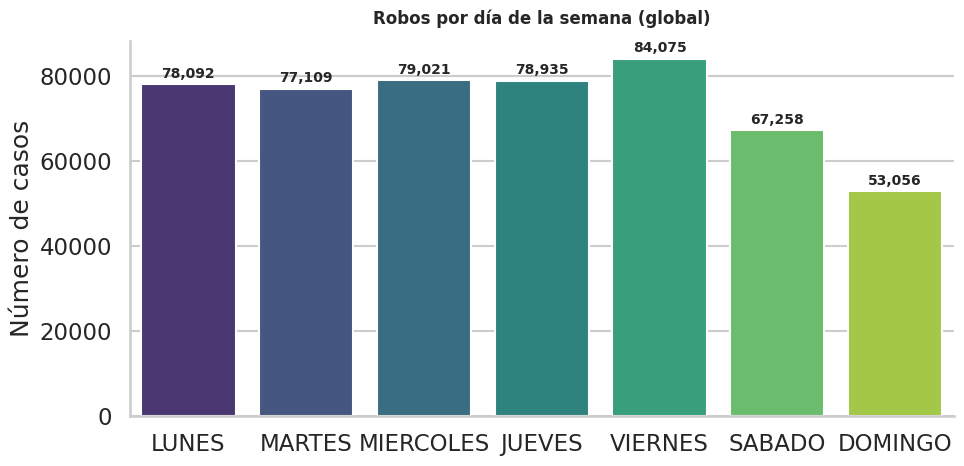

In [16]:
# Datos
dow_order = ["LUNES","MARTES","MIERCOLES","JUEVES","VIERNES","SABADO","DOMINGO"]
dow_counts = safe_value_counts(df_rt, "dia_semana").reindex(dow_order).fillna(0)
df_plot = dow_counts.reset_index()
df_plot.columns = ["Día", "Casos"]

plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=df_plot,
    x="Día", y="Casos",
    hue="Día",         # para aplicar paleta variada por barra
    dodge=False,
    palette="viridis"  # aesthetic
)

# Quitar leyenda si existe (evita AttributeError)
leg = ax.get_legend()
if leg is not None:
    leg.remove()

# Etiquetas encima de cada barra
for i, v in enumerate(df_plot["Casos"]):
    ax.text(
        i, v + max(1, v*0.01),  # pequeño offset
        f"{int(v):,}",          # separador de miles
        ha="center", va="bottom",
        fontsize=10, fontweight="bold"
    )

# Títulos y ejes
ax.set_title("Robos por día de la semana (global)", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("Número de casos")
sns.despine()
plt.tight_layout()
plt.show()


Este plot sugiere que los robos tienden a concentrarse en mayor medida en viernes, probablemente asociados con mayor flujo de personas y actividades económicas. Sin embargo, la incidencia cae de forma notable en fin de semana, especialmente el domingo. Esto refuerza la idea de que los días laborales (y en particular el viernes) concentran más oportunidades delictivas.

### ROBOS POR DIA vs ZONA COMERCIAL

In [17]:
is_vie_sab = ["VIERNES","SABADO"]

# --- Agregación base (conteos por zona x día) ---
dow_zone = (
    df_rt.groupby(["zona_comercial","dia_semana"])
         .size()
         .unstack(fill_value=0)
         .reindex(columns=dow_order, fill_value=0)
)

# Versión long para seaborn + posición numérica para sombrear bandas ---
df_long = (
    dow_zone.reset_index()
            .melt(id_vars="zona_comercial", var_name="dia", value_name="casos")
            .assign(xpos=lambda d: d["dia"].map({d:i for i,d in enumerate(dow_order)}))
)

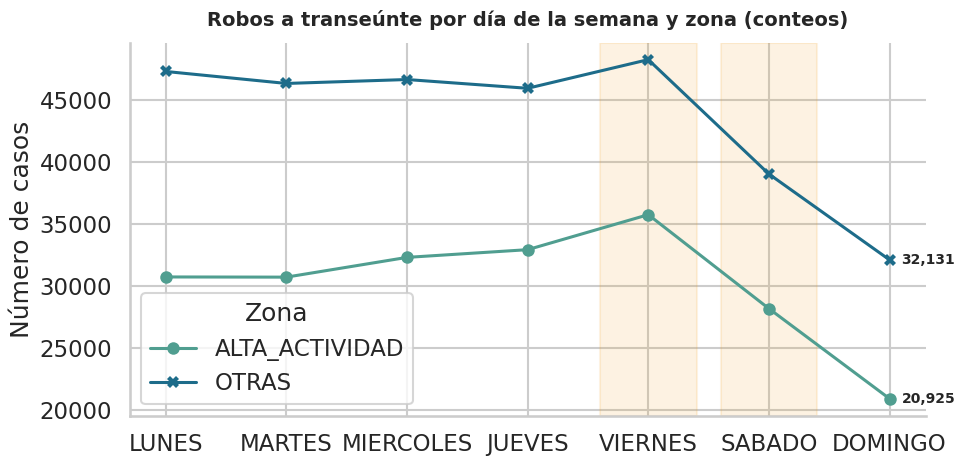

In [18]:
plt.figure(figsize=(10,5))
ax = sns.lineplot(
    data=df_long, x="xpos", y="casos",
    hue="zona_comercial", style="zona_comercial",
    markers=True, dashes=False, linewidth=2.2, markeredgewidth=0.0,
    palette="crest"
)

# Bandas sombreadas para VIERNES y SÁBADO (mejor lectura del pico)
vie_idx  = dow_order.index("VIERNES")
sab_idx  = dow_order.index("SABADO")
ax.axvspan(vie_idx-0.4, vie_idx+0.4, alpha=0.12, color="#f39c12")
ax.axvspan(sab_idx-0.4, sab_idx+0.4, alpha=0.12, color="#f39c12")

# Reemplazar ticks numéricos por etiquetas de días
ax.set_xticks(range(len(dow_order)))
ax.set_xticklabels(dow_order, rotation=0)

# Etiquetas de valor en el último punto de cada línea
for zona, g in df_long.groupby("zona_comercial"):
    g = g.sort_values("xpos")
    x_last, y_last = g["xpos"].iloc[-1], g["casos"].iloc[-1]
    ax.text(x_last+0.1, y_last, f"{int(y_last):,}", va="center", fontsize=10, weight="bold")

ax.set_title("Robos a transeúnte por día de la semana y zona (conteos)", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("Número de casos")
ax.legend(title="Zona")
sns.despine()
plt.tight_layout()
plt.show()

* Cada línea representa un tipo de zona:

  * ALTA_ACTIVIDAD → alcaldías con mucha actividad comercial.

  * OTRAS → todas las demás alcaldías.

* Los puntos (markers) sobre cada día muestran el valor puntual de robos.

* Áreas sombreadas:

  * Se resaltan viernes y sábado con una banda amarilla/naranja semitransparente.

  * Esto sirve para enfatizar la hipótesis: revisar si en esos días los robos se concentran más.

* Ambas curvas muestran que los robos a transeúnte ocurren durante toda la semana, pero la intensidad no es uniforme. Sin embargo, solamente los viernes la incidencia aumenta.


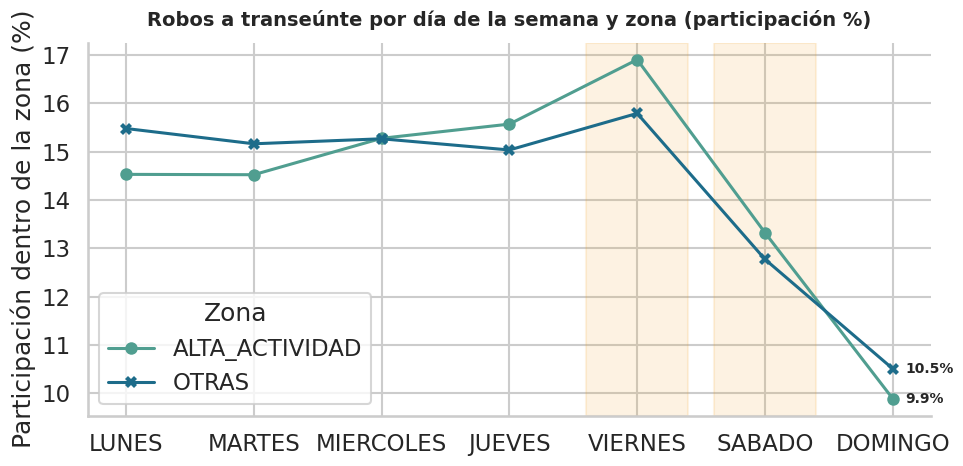

In [19]:
# LÍNEAS EN PORCENTAJE: Normaliza dentro de cada zona para comparar formas

df_long_norm = df_long.copy()
df_long_norm["pct"] = df_long_norm.groupby("zona_comercial")["casos"].transform(
    lambda s: np.where(s.sum()>0, 100*s/s.sum(), 0)
)

plt.figure(figsize=(10,5))
ax = sns.lineplot(
    data=df_long_norm, x="xpos", y="pct",
    hue="zona_comercial", style="zona_comercial",
    markers=True, dashes=False, linewidth=2.2, markeredgewidth=0.0,
    palette="crest"
)

ax.axvspan(vie_idx-0.4, vie_idx+0.4, alpha=0.12, color="#f39c12")
ax.axvspan(sab_idx-0.4, sab_idx+0.4, alpha=0.12, color="#f39c12")

ax.set_xticks(range(len(dow_order)))
ax.set_xticklabels(dow_order, rotation=0)

# Etiquetas (%) en el último punto
for zona, g in df_long_norm.groupby("zona_comercial"):
    g = g.sort_values("xpos")
    x_last, y_last = g["xpos"].iloc[-1], g["pct"].iloc[-1]
    ax.text(x_last+0.1, y_last, f"{y_last:,.1f}%", va="center", fontsize=10, weight="bold")

ax.set_title("Robos a transeúnte por día de la semana y zona (participación %)", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("Participación dentro de la zona (%)")
ax.legend(title="Zona")
sns.despine()
plt.tight_layout()
plt.show()

* En este plot no se muestra el número bruto de robos, sino el porcentaje que representa cada día respecto al total semanal de su zona.

  * Ejemplo: si en zonas de alta actividad hubo 10,000 robos en la semana y 1,700 fueron el viernes, eso equivale a ~17%.

* Patrones en zonas de alta actividad:

  * El viernes concentra el pico más alto: cerca de 17% de todos los robos de la semana en estas alcaldías.

  * El sábado también mantiene un nivel considerable, aunque menor que el viernes (~13%).

  * El domingo cae drásticamente (menos del 10%).

  * Esto respalda la idea de que el viernes es el día crítico en zonas comerciales, con un peso relativo superior.

* Patrones en otras zonas:

  * Son más estables de lunes a jueves (~15%).

  * También suben el viernes, aunque con menor intensidad que las zonas comerciales.

  * El fin de semana baja fuerte, especialmente el domingo (~10%).


* Comparación entre zonas:

  * El contraste es más claro en viernes:

     * Alta actividad = 17%

     * Otras zonas = 16%

  * Aunque la diferencia parezca pequeña, en términos relativos muestra que el viernes es más determinante en el patrón de las zonas comerciales.

  * Domingo es el día más bajo para ambas zonas, pero la caída es más pronunciada en las alcaldías comerciales.

### PERFIL HORARIO

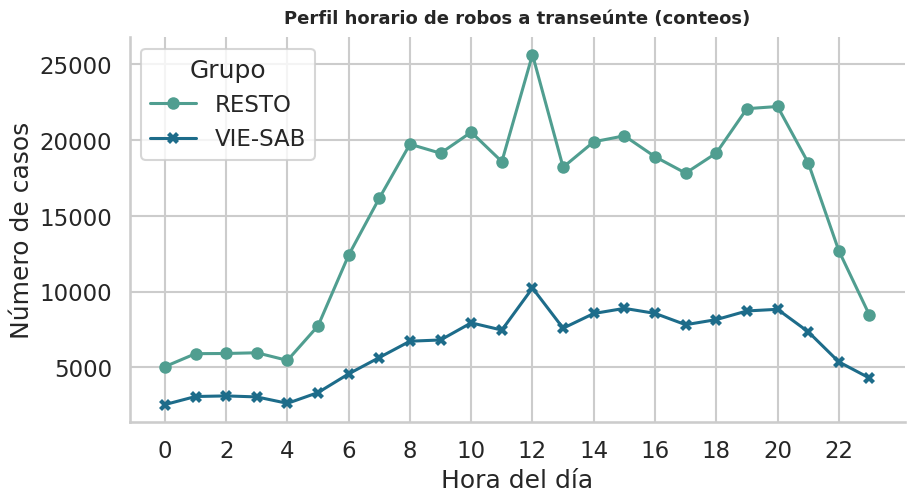

In [20]:
tmp = df_rt.copy()

# Asegurar horas válidas como enteros y crear el grupo de fin de semana pico
tmp = tmp[tmp["hora_num"].notna()].copy()
tmp["hora_num"] = tmp["hora_num"].astype(int)
tmp["grupo"] = np.where(tmp["dia_semana"].isin(["VIERNES","SABADO"]), "VIE-SAB", "RESTO")

# Agregar: index=hora, columns=grupo -> values=conteo
profile = (
    tmp.groupby(["hora_num","grupo"]).size()
       .unstack(fill_value=0)
       .reindex(range(24), fill_value=0)  # asegura 0..23
)

# Plot en conteos absolutos
plt.figure(figsize=(10,5))
ax = sns.lineplot(data=profile, dashes=False, markers=True, linewidth=2.2, markeredgewidth=0, palette="crest")

# Etiquetas y formato
ax.set_xticks(range(0,24,2))
ax.set_xlabel("Hora del día")
ax.set_ylabel("Número de casos")
ax.set_title("Perfil horario de robos a transeúnte (conteos)", fontsize=13, weight="bold", pad=10)
ax.legend(title="Grupo")
sns.despine()


* El gráfico muestra el perfil horario de robos a transeúnte, diferenciando dos grupos de días:

  * RESTO: de lunes a jueves y domingo.

  * VIE-SAB: viernes y sábado.


* El gráfico sugiere que los picos de robos ocurren alrededor del mediodía en toda la semana, pero en viernes y sábado el patrón se prolonga más hacia la noche, lo que respalda la hipótesis de que estos días tienen un comportamiento particular en zonas de riesgo.

  * En el grupo RESTO, los robos aumentan gradualmente desde la madrugada, alcanzan un pico alrededor del mediodía (~12:00 h), y luego se mantienen relativamente altos durante la tarde, antes de descender por la noche. Esto refleja una mayor incidencia en horarios de alta movilidad laboral y escolar.

  * En el grupo VIE-SAB, aunque los valores absolutos son menores que en el resto de la semana, se observa un patrón consistente: la curva crece desde la mañana y muestra su mayor concentración también en las horas del mediodía y primeras horas de la tarde.

  * En ambos grupos, la madrugada es la franja horaria con menor número de robos, lo que indica menor exposición de víctimas en la vía pública.

  * La diferencia más destacable es que en viernes y sábado los robos mantienen cierta relevancia también en la tarde-noche, lo que puede relacionarse con actividades recreativas y sociales que generan mayor flujo de personas en la vía pública.



<Figure size 640x480 with 0 Axes>

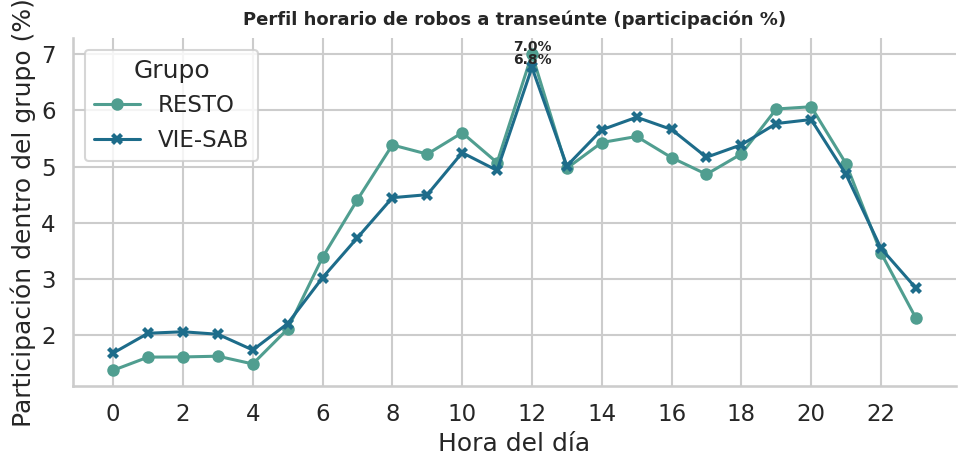

In [21]:
# Anotar/ETIQUETAR picos de cada línea
for col in profile.columns:
    peak_h = int(profile[col].idxmax())
    peak_v = int(profile[col].max())
    ax.text(peak_h, peak_v, f"{peak_v:,}", ha="center", va="bottom", fontsize=10, weight="bold")

plt.tight_layout()
plt.show()

# Plot en participación % (opcional, compara formas sin sesgo de volumen)
profile_pct = (profile / profile.sum(axis=0) * 100)

plt.figure(figsize=(10,5))
ax = sns.lineplot(data=profile_pct, dashes=False, markers=True, linewidth=2.2, markeredgewidth=0, palette="crest")
ax.set_xticks(range(0,24,2))
ax.set_xlabel("Hora del día")
ax.set_ylabel("Participación dentro del grupo (%)")
ax.set_title("Perfil horario de robos a transeúnte (participación %)", fontsize=13, weight="bold", pad=10)
ax.legend(title="Grupo")
sns.despine()

for col in profile_pct.columns:
    peak_h = int(profile_pct[col].idxmax())
    peak_v = profile_pct[col].max()
    ax.text(peak_h, peak_v, f"{peak_v:,.1f}%", ha="center", va="bottom", fontsize=10, weight="bold")

plt.tight_layout()
plt.show()

* El plot confirma que el mediodía es la hora de mayor concentración relativa de robos en toda la semana, pero en viernes y sábado el riesgo se mantiene más elevado también en horario nocturno. Esto refuerza la hipótesis de que estos días presentan un comportamiento particular en la dinámica delictiva.

* Escala relativa: el eje Y indica el porcentaje que cada hora representa dentro del total diario de cada grupo, no el número absoluto de robos. Eso permite comparar formas de distribución horaria aunque los volúmenes totales sean distintos.

* Madrugada (0–5 h): ambos grupos presentan niveles bajos (1.5%–2% del total), lo que confirma que la actividad delictiva en esas horas es marginal.

* Mañana (6–11 h): los robos comienzan a aumentar desde las 6 h y alcanzan valores de 4%–5% hacia media mañana, lo que coincide con mayor movilidad laboral y escolar.

* Mediodía (12–13 h): se observa el pico más alto en ambos grupos, con alrededor de 7% del total de robos concentrados en esa franja horaria. Esto indica que el mediodía es la hora crítica de mayor riesgo para transeúntes.

* Tarde (14–19 h): los porcentajes se mantienen relativamente altos (5%–6%), lo que refleja continuidad del riesgo durante las horas de salida laboral y actividades recreativas.

* Noche (20–23 h): los valores empiezan a descender, pero aún representan entre 3%–5% del total, lo que muestra que no desaparece la incidencia en la franja nocturna, aunque baja respecto al mediodía.

### HEADMAP DIA vs HORA

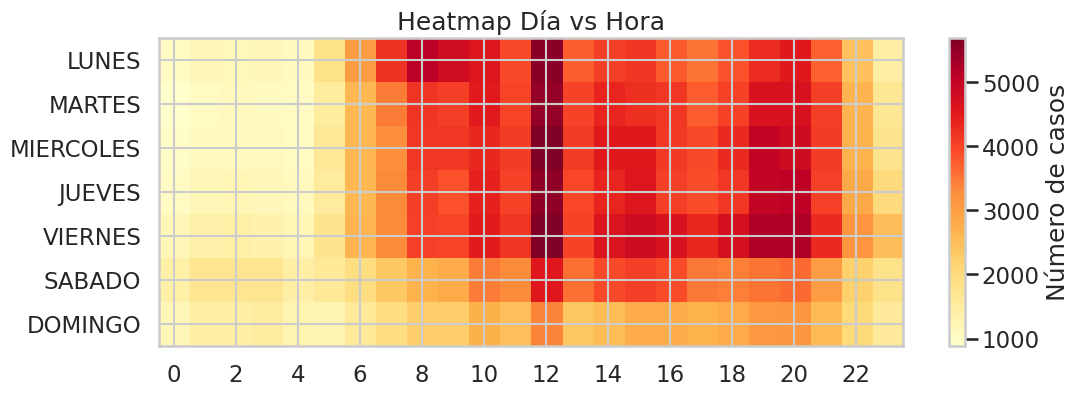

In [22]:
pivot_dh = (
    df_rt.groupby(["dia_semana","hora_num"])
         .size()
         .unstack(fill_value=0)
         .reindex(dow_order)
)

plt.figure(figsize=(12,4))
plt.imshow(pivot_dh.values, aspect="auto", cmap="YlOrRd")
plt.colorbar(label="Número de casos")
plt.xticks(range(0,24,2), labels=range(0,24,2))
plt.yticks(range(len(dow_order)), labels=dow_order)
plt.title("Heatmap Día vs Hora")
plt.show()


* El heatmap confirma que los robos a transeúnte se concentran principalmente entre la mañana y la tarde (8–20 h), con un pico alrededor del mediodía. Además, viernes y sábado destacan por mantener niveles relativamente altos también en horas nocturnas, mientras que el domingo se consolida como el día de menor incidencia.

* Patrones horarios:

  * La madrugada (0–5 h) se observa con colores oscuros en todos los días → mínima incidencia de robos.

  * A partir de las 6–7 h, comienza un aumento progresivo de casos.

  * El pico máximo se da alrededor del mediodía (12–13 h), donde el color alcanza el blanco, indicando la mayor concentración de robos.

  * Durante la tarde y primeras horas de la noche (14–20 h), la intensidad se mantiene alta, aunque algo menor que al mediodía.

  * Después de las 21–22 h se observa una caída marcada, regresando a valores bajos hacia la medianoche.

* Patrones por día de la semana:

  * De lunes a viernes el patrón es similar: fuerte concentración entre la mañana y la tarde.

  * Viernes y sábado muestran un poco más de intensidad hacia la noche (18–21 h), lo que podría estar vinculado con mayor actividad social y recreativa.

  * El domingo presenta menor intensidad global, con colores más oscuros, lo que indica una incidencia reducida en comparación con días laborales.

### TOP ALCALDÍAS y COLONIAS

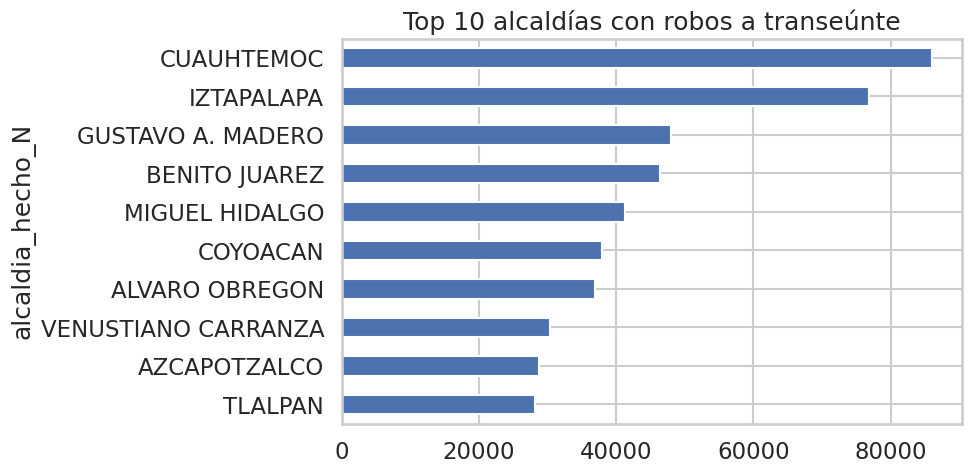

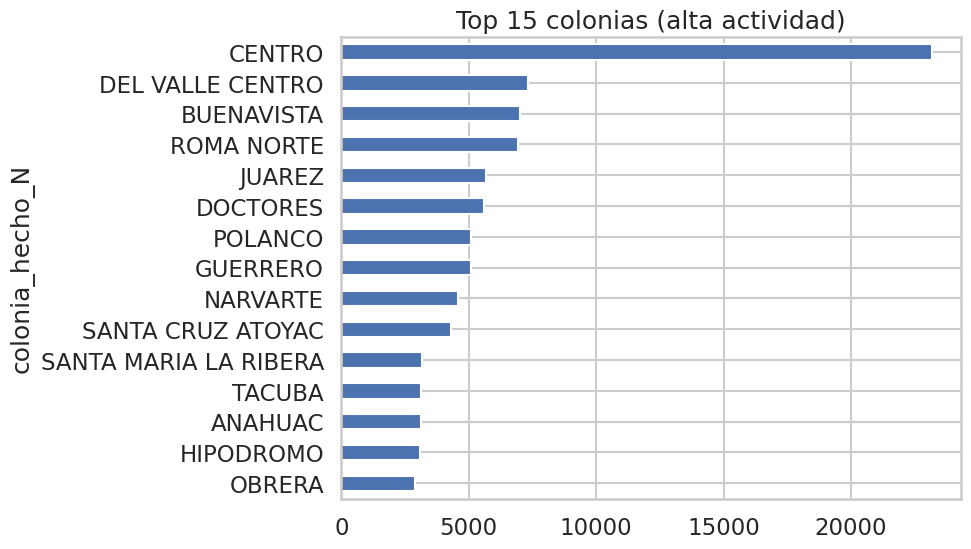

In [23]:
top_alcaldias = df_rt["alcaldia_hecho_N"].value_counts().head(10).sort_values()
top_alcaldias.plot(kind="barh", figsize=(8,5))
plt.title("Top 10 alcaldías con robos a transeúnte")
plt.show()

top_colonias_com = (
    df_rt[df_rt["zona_comercial"]=="ALTA_ACTIVIDAD"]["colonia_hecho_N"]
    .value_counts().head(15).sort_values()
)
top_colonias_com.plot(kind="barh", figsize=(8,6))
plt.title("Top 15 colonias (alta actividad)")
plt.show()


### MAPAS

In [24]:
# Subconjunto: zonas comerciales + VIE/SAB con coordenadas válidas
subset_map = df_rt[
    (df_rt["zona_comercial"] == "ALTA_ACTIVIDAD") &
    (df_rt["dia_semana"].isin(["VIERNES", "SABADO"])) &
    df_rt["latitud"].notna() & df_rt["longitud"].notna()
][["latitud", "longitud"]].copy()


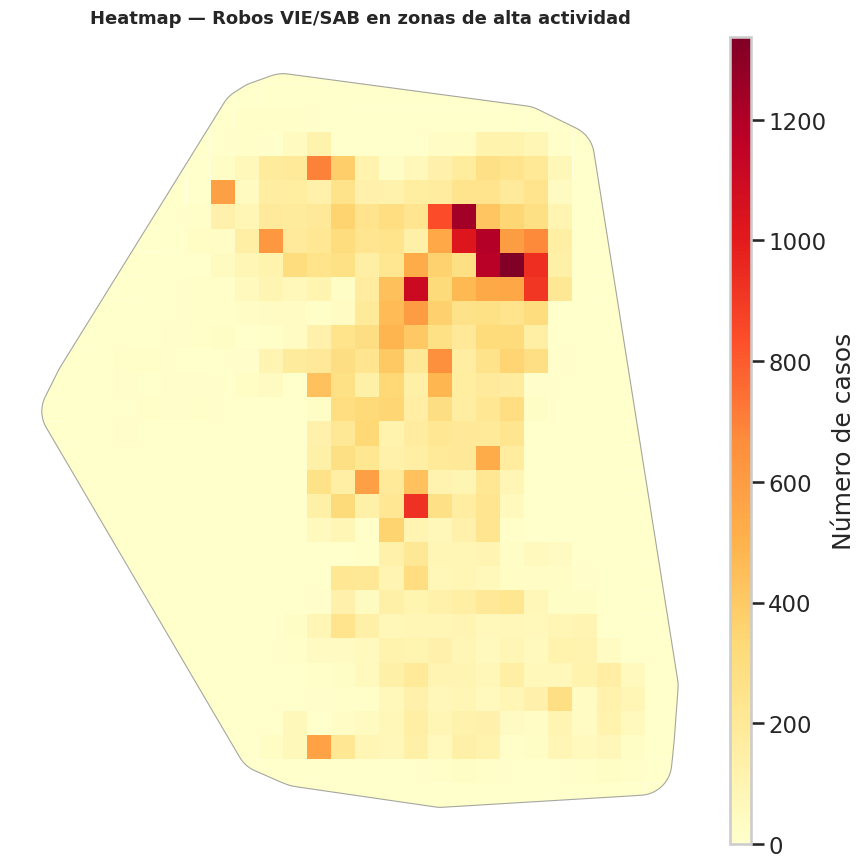

In [25]:
# USANDO GEOPANDAS

if subset_map.empty:
    raise ValueError("No hay puntos para graficar con los filtros actuales.")

# GeoDataFrame y proyección métrica (WebMercator)
gdf = gpd.GeoDataFrame(
    subset_map,
    geometry=gpd.points_from_xy(subset_map["longitud"], subset_map["latitud"]),
    crs="EPSG:4326"  # WGS84
).to_crs(3857)        # metros (útil para áreas y grillas)

# Área de interés y grilla (fishnet)
# Usamos el convex hull de los puntos + un pequeño buffer, para no “cortar” el mapa
aoi = gdf.unary_union.convex_hull.buffer(1000)  # 1 km de margen

# Tamaño de celda (en metros). Ajusta según lo “suave” que quieras el heatmap.
cell = 750  # 750 m por lado (prueba 500/1000 para más/menos detalle)

xmin, ymin, xmax, ymax = aoi.bounds
xs = np.arange(xmin, xmax + cell, cell)
ys = np.arange(ymin, ymax + cell, cell)

# Construimos la grilla de cuadrados (fishnet)
polys = []
for x in xs[:-1]:
    for y in ys[:-1]:
        polys.append(box(x, y, x + cell, y + cell))

grid = gpd.GeoDataFrame(geometry=polys, crs=3857)

# Recortamos la grilla al AOI ...  esto sirve para dejar el mapa más limpio
grid_clip = gpd.overlay(grid, gpd.GeoDataFrame(geometry=[aoi], crs=3857), how="intersection")

# Conteo de puntos por celda (spatial join)
join = gpd.sjoin(
    gdf[["geometry"]],
    grid_clip.reset_index().rename(columns={"index":"cell_id"}),
    predicate="within",
    how="left"
)

counts = join.groupby("cell_id").size()
grid_clip["casos"] = grid_clip.reset_index().merge(counts.rename("casos"),
                                                   left_on="index", right_index=True,
                                                   how="left")["casos"].fillna(0).astype(int)

# (Opcional) Densidad por km² en lugar de conteo:
# area_km2 = grid_clip.to_crs(3857).area / 1e6
# grid_clip["densidad_km2"] = grid_clip["casos"] / area_km2

# Plot choropleth (más rojo = más casos)
fig, ax = plt.subplots(figsize=(9, 10))
ax.set_aspect("equal")

# Paleta YlOrRd: Amarillo (bajo) → Rojo (alto)
norm = Normalize(vmin=grid_clip["casos"].min(), vmax=grid_clip["casos"].max())
grid_clip.plot(column="casos", cmap="YlOrRd", linewidth=0, ax=ax, norm=norm)

# Borde del AOI para contexto
gpd.GeoSeries(aoi, crs=3857).boundary.plot(ax=ax, color="gray", linewidth=0.8, alpha=0.7)

# Limpieza visual
ax.set_axis_off()
ax.set_title("Heatmap — Robos VIE/SAB en zonas de alta actividad", fontsize=13, weight="bold", pad=10)

# Barra de color manual (matplotlib)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.2)
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=norm)
sm._A = []
cb = plt.colorbar(sm, cax=cax)
cb.set_label("Número de casos", rotation=90)

plt.tight_layout()
plt.show()


In [27]:
# USANDO FOLLIUM

# Control de outliers para centrar mejor (recorta al 1%-99%)
q1_lat, q99_lat = subset_map["latitud"].quantile([0.01, 0.99])
q1_lon, q99_lon = subset_map["longitud"].quantile([0.01, 0.99])
subset_map = subset_map[
    subset_map["latitud"].between(q1_lat, q99_lat) &
    subset_map["longitud"].between(q1_lon, q99_lon)
].copy()

# Muestreo para performance si hay muchos puntos
N = 30000
if len(subset_map) > N:
    subset_map = subset_map.sample(N, random_state=42)

#  Centro robusto (mediana); fallback al Zócalo si hiciera falta
if len(subset_map) > 0:
    center_lat = float(subset_map["latitud"].median())
    center_lon = float(subset_map["longitud"].median())
else:
    center_lat, center_lon = 19.4326, -99.1332  # CDMX (Zócalo) como respaldo

#  Mapa con tiles claros y control de capas
mapa = folium.Map(location=[center_lat, center_lon], zoom_start=12, control_scale=True, tiles=None)
folium.TileLayer("CartoDB positron", name="Base clara").add_to(mapa)
folium.TileLayer("OpenStreetMap", name="OSM").add_to(mapa)

# Ajuste automático de encuadre usando bounds sin outliers
lat_min, lat_max = subset_map["latitud"].min(), subset_map["latitud"].max()
lon_min, lon_max = subset_map["longitud"].min(), subset_map["longitud"].max()
mapa.fit_bounds([[lat_min, lon_min], [lat_max, lon_max]])

# Heatmap más legible (gradiente rojo en valores altos)
# Amarillo (bajo) -> Naranja (medio) -> Rojo (alto)
gradient = {
    0.00: "#fff7bc",
    0.25: "#fee391",
    0.50: "#fec44f",
    0.75: "#fdae6b",
    0.90: "#f16913",
    1.00: "#d94801",
}

HeatMap(
    data=subset_map[["latitud", "longitud"]].values.tolist(),
    radius=12,       # mayor radio para manchas más continuas
    blur=18,         # suaviza
    max_zoom=13,
    min_opacity=0.3,
    gradient=gradient
).add_to(folium.FeatureGroup(name="Heatmap VIE-SAB (alta actividad)").add_to(mapa))

# Control para alternar capas ===
folium.LayerControl(collapsed=False).add_to(mapa)

# Mostrar y opcionalmente guardar ===
#mapa.save("mapa_vie_sab_zona_comercial_cdmx.html")
mgradient = {
    0.00: "#fff7bc",
    0.25: "#fee391",
    0.50: "#fec44f",
    0.75: "#fdae6b",
    0.90: "#f16913",
    1.00: "#d94801",
}

HeatMap(
    data=subset_map[["latitud", "longitud"]].values.tolist(),
    radius=12,       # mayor radio para manchas más continuas
    blur=6,         # suaviza
    max_zoom=13,
    min_opacity=0.3,
    gradient=gradient
).add_to(folium.FeatureGroup(name="Heatmap VIE-SAB (alta actividad)").add_to(mapa))

# Control para alternar capas ===
folium.LayerControl(collapsed=False).add_to(mapa)

#visualizar el mapa
mapa

* El área resaltada se concentra en la parte central de la ciudad, abarcando colonias y delegaciones como Polanco, Condesa, Narvarte, Del Valle y Coyoacán, entre otras.

* Los tonos más oscuros/naranjas intensos marcan las áreas con mayor densidad de incidentes. Ya los tonos más claros corresponden a áreas con menor densidad relativa.

* La concentración más fuerte se observa en la zona central de la ciudad (alrededor del Centro, Polanco, Condesa y Narvarte). Estas áreas son reconocidas por su alta actividad comercial, laboral y recreativa, lo que las convierte en zonas de mayor exposición al delito.

* El patrón se atenúa hacia el sur (Coyoacán, San Ángel) y hacia el poniente (Santa Fe), aunque todavía se marcan como áreas relevantes.

* En contraste, las zonas periféricas (como el oriente o el norte más alejado) muestran menor intensidad en este mapa específico.

# 4) Discusión

* El análisis gráfico de la incidencia de robos a transeúnte en la Ciudad de México muestra patrones temporales y espaciales consistentes.

* Distribución por día de la semana: Los resultados indican que el viernes concentra la mayor cantidad de robos, seguido del sábado, mientras que el domingo presenta la menor incidencia. Esto sugiere que los días de mayor movilidad laboral, recreativa y comercial generan más oportunidades delictivas.

* Comparación por zonas: Al contrastar las alcaldías de alta actividad comercial con el resto de la ciudad, se observa que ambas mantienen un patrón semanal similar, pero en las zonas comerciales el repunte de viernes es más pronunciado, pero una relatiba "baja" en los sábados, confirmando parcialmente la hipótesis planteada.

* Perfil horario: El desglose por horas evidencia que los robos se concentran en el mediodía y la tarde (12:00–19:00 h), coincidiendo con los periodos de mayor afluencia de personas en calles y comercios. En viernes y sábado, la curva se prolonga hacia la noche, lo cual sugiere que las actividades recreativas y sociales del fin de semana extienden la exposición al riesgo.

* Heatmap día × hora: El mapa de calor confirma que el riesgo es bajo en la madrugada, crece desde primeras horas de la mañana y alcanza su máxima intensidad al mediodía, manteniéndose elevado hasta la tarde. Los viernes y sábados destacan por conservar mayor intensidad en franjas nocturnas respecto a otros días.

* Patrón espacial: El mapa geográfico revela una concentración de incidentes en las zonas centrales y de alta actividad comercial, como Cuauhtémoc, Benito Juárez y Miguel Hidalgo, lo cual coincide con áreas de alta densidad laboral, comercial y recreativa. Esto respalda la hipótesis de que el contexto urbano influye en la dinámica delictiva.

* En conjunto, los resultados aportan evidencia descriptiva a favor de la hipótesis: los robos a transeúnte tienden a concentrarse en viernes y sábado, especialmente en las alcaldías con mayor actividad comercial. Sin embargo, también se observa que la incidencia es relevante en el resto de la semana y en diversas zonas de la ciudad.

# 5) Consideraciones Finales

* **Confirmación parcial de la hipótesis:** Los datos muestran un incremento claro de robos en viernes y sábado en las zonas comerciales, lo que da soporte a la hipótesis. Sin embargo, la magnitud del fenómeno en otros días y zonas sugiere que no es un patrón exclusivo.


* La categoría de “alta actividad comercial” se definió de manera aproximada, sin un indicador objetivo (ej. número de unidades económicas o aforos peatonales).

* No se normalizó la incidencia por población o flujos de movilidad, lo cual sería necesario para hablar de riesgo relativo.


* Próximos pasos:

  * Integrar datos externos (DENUE, movilidad, aforos) para definir con mayor precisión las zonas de alta actividad.

  * Normalizar por población residente y flotante para calcular tasas y no solo conteos absolutos.

  * Explorar modelos predictivos que permitan anticipar concentraciones de riesgo según día, hora y zona.